# Notebook 02: Head Ablation + Erasure Sweep

**This is where our unique contribution lives.**

Plan:
1. Validate induction heads with ablation on clean tokens
2. Sweep erasure rate (eps) and measure how induction degrades
3. At each eps, measure each head's contribution — do any heads become *harmful*?

**Primary hypothesis:** Increasing eps degrades induction, and this is explained
by reduced contribution from induction-relevant heads.

**Secondary hypothesis:** Beyond some eps threshold, some heads become harmful
(ablating them *improves* performance), indicating unreliable routing under
missing-context conditions.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

from src.data import make_induction_tokens
from src.metrics import induction_positions_and_targets, logit_diff
from src.corruptions import corrupt_prefix_random_replace, corrupt_prefix_fixed_token
from src.ablation import ablate_head, compute_ablation_effects

/home/mkarakas/projects/machine_interp/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HookedTransformer.from_pretrained('gpt2-small', device=device)

N_CTX_HALF = 50
BATCH = 30

tokens = make_induction_tokens(
    batch=BATCH,
    n_ctx_half=N_CTX_HALF,
    bos_token_id=model.tokenizer.bos_token_id,
    seed=42,
).to(device)

eval_positions, eval_targets = induction_positions_and_targets(tokens.cpu(), N_CTX_HALF)
eval_positions = eval_positions.to(device)
eval_targets = eval_targets.to(device)

def metric_fn(logits):
    return logit_diff(logits, eval_positions, eval_targets)

print(f'Device: {device}, GPU: {torch.cuda.get_device_name(0)}')

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2-small into HookedTransformer
Device: cuda, GPU: NVIDIA RTX A6000


## Part 1: Ablation on clean tokens

First, let's validate: which heads matter for induction when the input is clean?

We ablate (zero out) each head one at a time and measure the drop in logit_diff.
A big drop = that head is important for induction.

In [3]:
# Test ALL 144 heads on clean tokens
print('Ablating all heads on clean tokens...')
clean_results = compute_ablation_effects(model, tokens, metric_fn)

print(f'\nBaseline logit diff (no ablation): {clean_results["baseline"]:.3f}')

# Sort by contribution (most helpful first)
sorted_heads = sorted(
    clean_results['contributions'].items(),
    key=lambda x: x[1],
    reverse=True
)

print('\nTop 10 most helpful heads (ablation hurts the most):')
for (layer, head), contrib in sorted_heads[:10]:
    print(f'  L{layer}H{head}: contribution = {contrib:.3f}')

print('\nTop 5 most harmful heads (ablation helps):')
for (layer, head), contrib in sorted_heads[-5:]:
    print(f'  L{layer}H{head}: contribution = {contrib:.3f}')

Ablating all heads on clean tokens...

Baseline logit diff (no ablation): 21.541

Top 10 most helpful heads (ablation hurts the most):
  L5H1: contribution = 7.237
  L4H11: contribution = 4.595
  L7H6: contribution = 4.021
  L5H9: contribution = 3.897
  L1H10: contribution = 3.577
  L0H1: contribution = 3.465
  L6H7: contribution = 2.837
  L8H5: contribution = 2.626
  L0H3: contribution = 1.930
  L1H4: contribution = 1.587

Top 5 most harmful heads (ablation helps):
  L2H11: contribution = -1.088
  L7H3: contribution = -1.097
  L4H7: contribution = -1.377
  L0H8: contribution = -1.397
  L0H11: contribution = -2.397


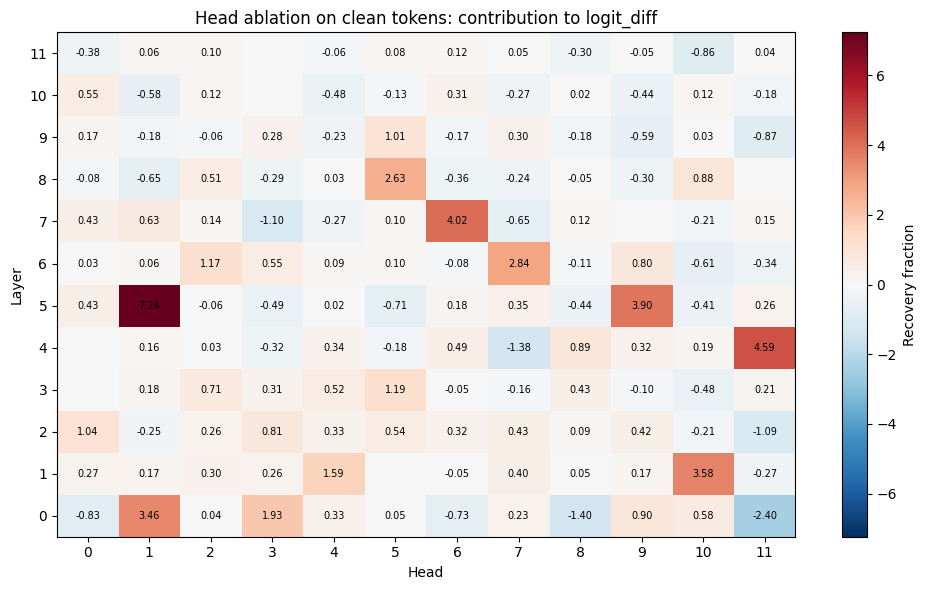

In [4]:
# Visualize as a heatmap
from src.plotting import plot_head_patching_heatmap

contrib_grid = torch.zeros(model.cfg.n_layers, model.cfg.n_heads)
for (layer, head), contrib in clean_results['contributions'].items():
    contrib_grid[layer, head] = contrib

plot_head_patching_heatmap(
    contrib_grid,
    title='Head ablation on clean tokens: contribution to logit_diff',
    save_path='../results/figures/fig3a_clean_ablation.png',
)

## Part 2: Erasure sweep — how does induction degrade?

Now the core experiment. We sweep the erasure rate from 0 (no corruption)
to 1 (all first-half tokens replaced), and at each level:

1. Measure the overall induction metric (logit_diff)
2. For the top heads identified above, measure each head's contribution

We use two corruption types for robustness:
- **Random replace**: each corrupted token → random vocab token
- **Fixed replace**: each corrupted token → the token "the"

In [5]:
# Select top heads to track (top 10 by clean contribution)
top_heads = [(l, h) for (l, h), _ in sorted_heads[:10]]
print('Tracking heads:', [f'L{l}H{h}' for l, h in top_heads])

# Erasure rates to sweep
eps_values = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.7, 0.85, 1.0]

# Get the token id for "the" (for fixed replacement)
the_token_id = model.tokenizer.encode(' the')[0]
print(f'Token ID for " the": {the_token_id}')

Tracking heads: ['L5H1', 'L4H11', 'L7H6', 'L5H9', 'L1H10', 'L0H1', 'L6H7', 'L8H5', 'L0H3', 'L1H4']
Token ID for " the": 262


In [6]:
def run_erasure_sweep(corruption_fn, corruption_name, eps_values, top_heads):
    """
    For each erasure rate, compute:
    - baseline metric (with corruption, no ablation)
    - each head's contribution (with corruption + ablation)
    """
    results = {
        'eps': eps_values,
        'baseline_metric': [],
        'contributions': {h: [] for h in top_heads},
    }

    for eps in eps_values:
        # Generate corrupted tokens
        if eps == 0.0:
            corrupt_tok = tokens  # no corruption
        else:
            corrupt_tok = corruption_fn(tokens.cpu(), n_ctx_half=N_CTX_HALF, eps=eps, seed=42).to(device)

        # Compute ablation effects on corrupted tokens
        effects = compute_ablation_effects(model, corrupt_tok, metric_fn, candidate_heads=top_heads)

        results['baseline_metric'].append(effects['baseline'])
        for h in top_heads:
            results['contributions'][h].append(effects['contributions'][h])

        n_harmful = sum(1 for h in top_heads if effects['contributions'][h] < 0)
        print(f'  eps={eps:.2f}: metric={effects["baseline"]:.3f}, harmful heads: {n_harmful}/{len(top_heads)}')

    return results

print('=== Random replacement ===')
results_random = run_erasure_sweep(
    corrupt_prefix_random_replace, 'random_replace', eps_values, top_heads
)

print('\n=== Fixed token replacement ===')
results_fixed = run_erasure_sweep(
    lambda tokens, n_ctx_half, eps, seed: corrupt_prefix_fixed_token(
        tokens, n_ctx_half, the_token_id, eps, seed
    ),
    'fixed_replace', eps_values, top_heads
)

=== Random replacement ===
  eps=0.00: metric=21.541, harmful heads: 0/10
  eps=0.05: metric=17.155, harmful heads: 0/10
  eps=0.10: metric=13.963, harmful heads: 0/10
  eps=0.15: metric=11.550, harmful heads: 0/10
  eps=0.20: metric=9.652, harmful heads: 0/10
  eps=0.30: metric=6.566, harmful heads: 0/10
  eps=0.40: metric=4.319, harmful heads: 0/10
  eps=0.50: metric=3.033, harmful heads: 0/10
  eps=0.70: metric=0.969, harmful heads: 2/10
  eps=0.85: metric=0.296, harmful heads: 3/10
  eps=1.00: metric=0.094, harmful heads: 2/10

=== Fixed token replacement ===
  eps=0.00: metric=21.541, harmful heads: 0/10
  eps=0.05: metric=16.659, harmful heads: 0/10
  eps=0.10: metric=13.231, harmful heads: 0/10
  eps=0.15: metric=10.620, harmful heads: 0/10
  eps=0.20: metric=8.688, harmful heads: 0/10
  eps=0.30: metric=5.836, harmful heads: 0/10
  eps=0.40: metric=3.814, harmful heads: 0/10
  eps=0.50: metric=2.738, harmful heads: 1/10
  eps=0.70: metric=1.002, harmful heads: 3/10
  eps=0.85: 

## Part 3: Plot the results

### Figure 3a: Induction metric vs erasure rate

How does overall induction performance degrade with corruption?

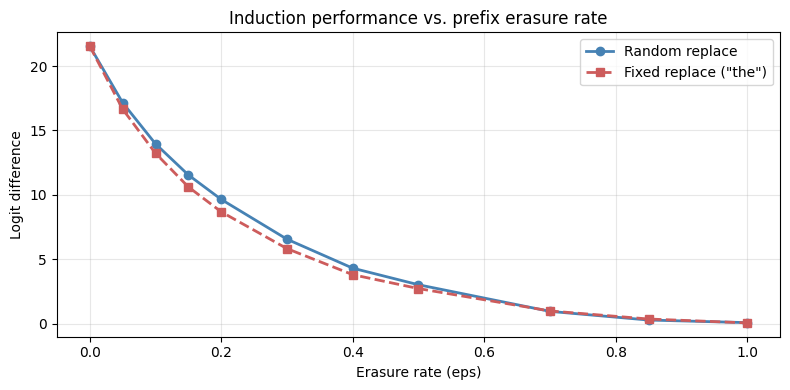

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(results_random['eps'], results_random['baseline_metric'],
        'o-', label='Random replace', color='steelblue', linewidth=2)
ax.plot(results_fixed['eps'], results_fixed['baseline_metric'],
        's--', label='Fixed replace ("the")', color='indianred', linewidth=2)

ax.set_xlabel('Erasure rate (eps)')
ax.set_ylabel('Logit difference')
ax.set_title('Induction performance vs. prefix erasure rate')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/fig3b_metric_vs_eps.png', dpi=150)
plt.show()

### Figure 3b: Head contributions vs erasure rate

This is the key figure. For each head, how does its contribution change?

- Lines above zero: head is helpful (ablating it hurts)
- Lines that cross below zero: head becomes **harmful** (ablating it helps!)

If we see sign flips, that supports our secondary hypothesis about unreliable routing.

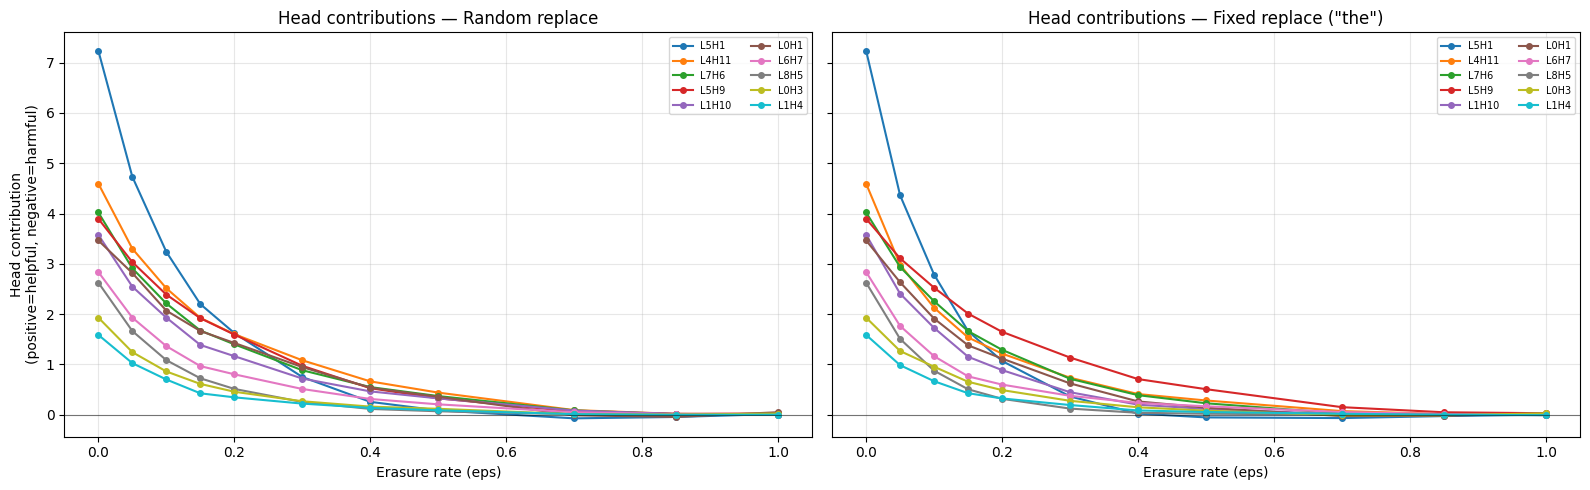

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, results, title in [
    (axes[0], results_random, 'Random replace'),
    (axes[1], results_fixed, 'Fixed replace ("the")'),
]:
    for (layer, head), contribs in results['contributions'].items():
        ax.plot(results['eps'], contribs, 'o-', label=f'L{layer}H{head}',
                markersize=4, linewidth=1.5)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Erasure rate (eps)')
    ax.set_title(f'Head contributions — {title}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, ncol=2)

axes[0].set_ylabel('Head contribution\n(positive=helpful, negative=harmful)')

plt.tight_layout()
plt.savefig('../results/figures/fig3c_head_contributions_vs_eps.png', dpi=150)
plt.show()

### Figure 3c: Count of harmful heads vs erasure rate

How many of our top heads become harmful (contribution < 0) at each eps?

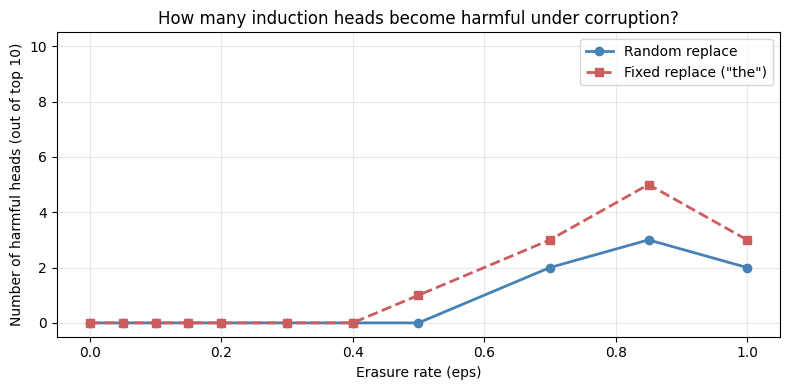

In [9]:
def count_harmful(results):
    counts = []
    for i in range(len(results['eps'])):
        n = sum(1 for h in top_heads if results['contributions'][h][i] < 0)
        counts.append(n)
    return counts

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(results_random['eps'], count_harmful(results_random),
        'o-', label='Random replace', color='steelblue', linewidth=2)
ax.plot(results_fixed['eps'], count_harmful(results_fixed),
        's--', label='Fixed replace ("the")', color='indianred', linewidth=2)

ax.set_xlabel('Erasure rate (eps)')
ax.set_ylabel('Number of harmful heads (out of top 10)')
ax.set_title('How many induction heads become harmful under corruption?')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, len(top_heads) + 0.5)

plt.tight_layout()
plt.savefig('../results/figures/fig3d_harmful_count_vs_eps.png', dpi=150)
plt.show()

## Part 4: Statistical robustness — multiple random seeds

Run the sweep with different random seeds to check if results are stable.

In [10]:
# Run with 5 different seeds and compute mean + std
seeds = [42, 123, 456, 789, 1337]
all_baselines = {seed: [] for seed in seeds}
all_harmful_counts = {seed: [] for seed in seeds}

for seed in seeds:
    for eps in eps_values:
        if eps == 0.0:
            corrupt_tok = tokens
        else:
            corrupt_tok = corrupt_prefix_random_replace(
                tokens.cpu(), n_ctx_half=N_CTX_HALF, eps=eps, seed=seed
            ).to(device)

        effects = compute_ablation_effects(model, corrupt_tok, metric_fn, candidate_heads=top_heads)
        all_baselines[seed].append(effects['baseline'])
        n_harmful = sum(1 for h in top_heads if effects['contributions'][h] < 0)
        all_harmful_counts[seed].append(n_harmful)

    print(f'Seed {seed} done')

# Compute mean and std across seeds
baseline_matrix = np.array([all_baselines[s] for s in seeds])  # [n_seeds, n_eps]
harmful_matrix = np.array([all_harmful_counts[s] for s in seeds])

baseline_mean = baseline_matrix.mean(axis=0)
baseline_std = baseline_matrix.std(axis=0)
harmful_mean = harmful_matrix.mean(axis=0)
harmful_std = harmful_matrix.std(axis=0)

Seed 42 done
Seed 123 done
Seed 456 done
Seed 789 done
Seed 1337 done


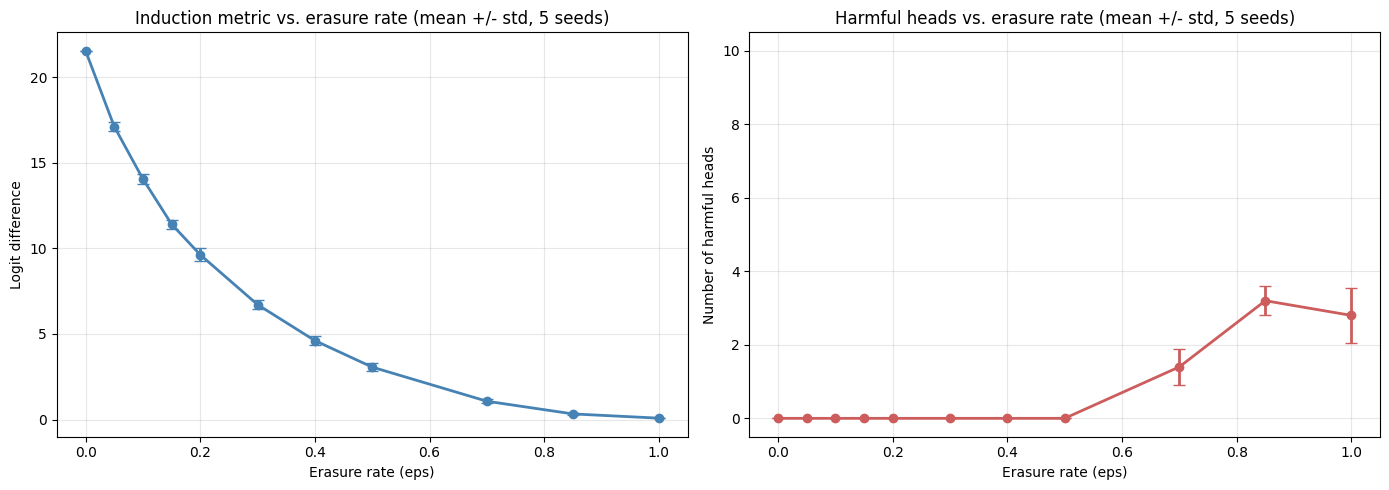

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: metric vs eps with error bars
ax = axes[0]
ax.errorbar(eps_values, baseline_mean, yerr=baseline_std,
            fmt='o-', color='steelblue', linewidth=2, capsize=4)
ax.set_xlabel('Erasure rate (eps)')
ax.set_ylabel('Logit difference')
ax.set_title('Induction metric vs. erasure rate (mean +/- std, 5 seeds)')
ax.grid(True, alpha=0.3)

# Right: harmful head count vs eps with error bars
ax = axes[1]
ax.errorbar(eps_values, harmful_mean, yerr=harmful_std,
            fmt='o-', color='indianred', linewidth=2, capsize=4)
ax.set_xlabel('Erasure rate (eps)')
ax.set_ylabel('Number of harmful heads')
ax.set_title('Harmful heads vs. erasure rate (mean +/- std, 5 seeds)')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, len(top_heads) + 0.5)

plt.tight_layout()
plt.savefig('../results/figures/fig3_erasure_sweep.png', dpi=150)
plt.show()

## Part 5: Fine-grained sweep with more seeds

The transition from 0 to several harmful heads happens somewhere around eps=0.5–0.85.
Let's zoom in with finer resolution and more seeds to:
1. Pin down where the transition actually occurs
2. Check if the dip at eps=1.0 is real or noise (likely noise — metric is ~0 there)

In [12]:
# Finer eps grid — especially dense in the transition zone (0.4–1.0)
eps_fine = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45,
            0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

# 10 seeds for better statistics
seeds_fine = list(range(10))

all_baselines_fine = {seed: [] for seed in seeds_fine}
all_harmful_counts_fine = {seed: [] for seed in seeds_fine}
# Also track per-head contributions across seeds for the transition analysis
all_contributions_fine = {seed: {h: [] for h in top_heads} for seed in seeds_fine}

for seed in seeds_fine:
    for eps in eps_fine:
        if eps == 0.0:
            corrupt_tok = tokens
        else:
            corrupt_tok = corrupt_prefix_random_replace(
                tokens.cpu(), n_ctx_half=N_CTX_HALF, eps=eps, seed=seed
            ).to(device)

        effects = compute_ablation_effects(model, corrupt_tok, metric_fn, candidate_heads=top_heads)
        all_baselines_fine[seed].append(effects['baseline'])
        n_harmful = sum(1 for h in top_heads if effects['contributions'][h] < 0)
        all_harmful_counts_fine[seed].append(n_harmful)
        for h in top_heads:
            all_contributions_fine[seed][h].append(effects['contributions'][h])

    print(f'Seed {seed} done')

# Aggregate
baseline_fine = np.array([all_baselines_fine[s] for s in seeds_fine])
harmful_fine = np.array([all_harmful_counts_fine[s] for s in seeds_fine])

baseline_fine_mean = baseline_fine.mean(axis=0)
baseline_fine_std = baseline_fine.std(axis=0)
harmful_fine_mean = harmful_fine.mean(axis=0)
harmful_fine_std = harmful_fine.std(axis=0)

print(f'\nDone. {len(seeds_fine)} seeds x {len(eps_fine)} eps values = {len(seeds_fine)*len(eps_fine)} conditions')

Seed 0 done
Seed 1 done
Seed 2 done
Seed 3 done
Seed 4 done
Seed 5 done
Seed 6 done
Seed 7 done
Seed 8 done
Seed 9 done

Done. 10 seeds x 21 eps values = 210 conditions


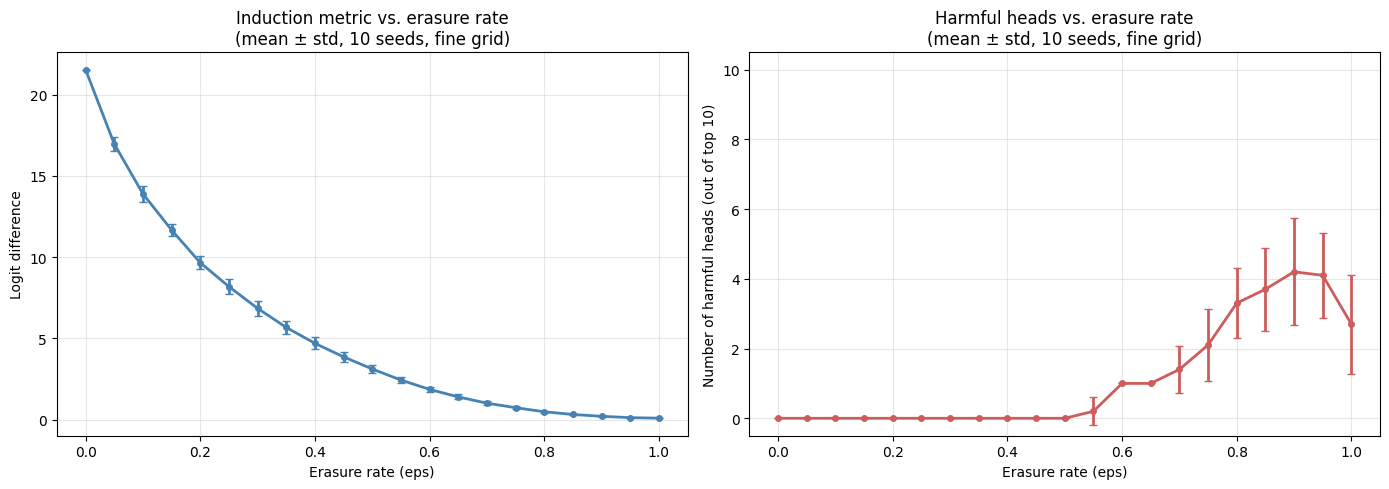

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: metric vs eps
ax = axes[0]
ax.errorbar(eps_fine, baseline_fine_mean, yerr=baseline_fine_std,
            fmt='o-', color='steelblue', linewidth=2, capsize=3, markersize=4)
ax.set_xlabel('Erasure rate (eps)')
ax.set_ylabel('Logit difference')
ax.set_title('Induction metric vs. erasure rate\n(mean ± std, 10 seeds, fine grid)')
ax.grid(True, alpha=0.3)

# Right: harmful head count vs eps
ax = axes[1]
ax.errorbar(eps_fine, harmful_fine_mean, yerr=harmful_fine_std,
            fmt='o-', color='indianred', linewidth=2, capsize=3, markersize=4)
ax.set_xlabel('Erasure rate (eps)')
ax.set_ylabel('Number of harmful heads (out of top 10)')
ax.set_title('Harmful heads vs. erasure rate\n(mean ± std, 10 seeds, fine grid)')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, len(top_heads) + 0.5)

plt.tight_layout()
plt.savefig('../results/figures/fig3_erasure_sweep_fine.png', dpi=150)
plt.show()

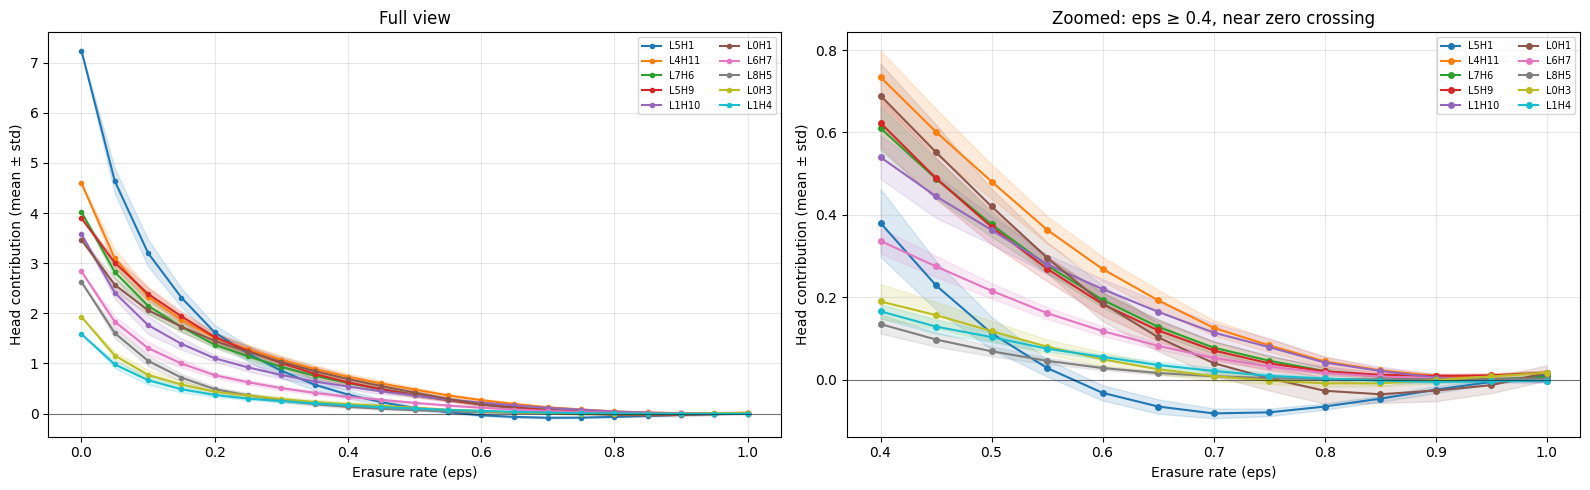

In [14]:
# Per-head contribution curves (mean across seeds) — shows which heads flip
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: full view
ax = axes[0]
for (layer, head) in top_heads:
    contribs_per_seed = np.array([all_contributions_fine[s][(layer, head)] for s in seeds_fine])
    mean_contrib = contribs_per_seed.mean(axis=0)
    std_contrib = contribs_per_seed.std(axis=0)

    line, = ax.plot(eps_fine, mean_contrib, 'o-', label=f'L{layer}H{head}',
                    markersize=3, linewidth=1.5)
    ax.fill_between(eps_fine, mean_contrib - std_contrib, mean_contrib + std_contrib,
                    alpha=0.15, color=line.get_color())

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Erasure rate (eps)')
ax.set_ylabel('Head contribution (mean ± std)')
ax.set_title('Full view')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# Right: zoomed in around zero for eps >= 0.4
ax = axes[1]
zoom_mask = [i for i, e in enumerate(eps_fine) if e >= 0.4]
eps_zoom = [eps_fine[i] for i in zoom_mask]

for (layer, head) in top_heads:
    contribs_per_seed = np.array([all_contributions_fine[s][(layer, head)] for s in seeds_fine])
    mean_contrib = contribs_per_seed.mean(axis=0)
    std_contrib = contribs_per_seed.std(axis=0)

    mean_zoom = mean_contrib[zoom_mask]
    std_zoom = std_contrib[zoom_mask]

    line, = ax.plot(eps_zoom, mean_zoom, 'o-', label=f'L{layer}H{head}',
                    markersize=4, linewidth=1.5)
    ax.fill_between(eps_zoom, mean_zoom - std_zoom, mean_zoom + std_zoom,
                    alpha=0.15, color=line.get_color())

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Erasure rate (eps)')
ax.set_ylabel('Head contribution (mean ± std)')
ax.set_title('Zoomed: eps ≥ 0.4, near zero crossing')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/fig3_head_contributions_fine.png', dpi=150)
plt.show()

## Summary of findings

1. **Primary hypothesis** (induction degrades with eps): **Confirmed**
   - Logit diff at eps=0: ~21.5
   - Logit diff at eps=1: ~0.09
   - Degradation shape: concave decay — steep initial drop that slows at higher eps

2. **Secondary hypothesis** (some heads become harmful): **Confirmed**
   - Harmful heads at eps=0: 0
   - Harmful heads emerge around eps=0.5–0.7
   - Holds across both corruption types (random and fixed replacement)

3. **Robustness**: Pending — check error bars from fine-grained sweep above

## Part 6: Conditional analysis — good vs bad mirror positions

The aggregate ablation effects show that L5H1 goes from strongly helpful (+7.24) 
to slightly harmful (~-0.13) as erasure rate increases. But *why*?

**Key insight:** At any given erasure rate, some second-half positions still have their 
mirror token intact in the first half ("good" positions), while others have it corrupted 
("bad" positions). An induction head should:

- **Help on good positions** — the mirror match is there, so the head finds it and copies correctly
- **Hurt on bad positions** — the mirror is gone, so the head attends to a *wrong* match and confidently copies the wrong token

As eps increases, more positions become "bad", so the net contribution shifts from positive to negative.

This analysis splits positions by mirror status and measures each head's contribution separately.

In [15]:
from src.metrics import logit_diff_per_position
from src.ablation import ablate_head_logits


def conditional_contributions(model, clean_tokens, corrupted_tokens, layer, head,
                              eval_positions, eval_targets, n_ctx_half):
    """
    Compute head contribution split by whether the mirror token survived corruption.
    
    For evaluation position k in the second half, the mirror is the first-half
    token at position 1+k. If that was corrupted, the induction head can't find
    the right match → "bad" position. If intact → "good" position.
    
    Returns: (good_mean, bad_mean, n_good, n_bad)
    """
    # Which first-half positions were corrupted?
    # Compare corrupted vs clean at positions 1..n_ctx_half
    mask = (corrupted_tokens[:, 1:1+n_ctx_half] != clean_tokens[:, 1:1+n_ctx_half])
    
    # For eval position k, the mirror is at first-half index k
    # We have n_ctx_half-1 eval positions (indices 0..n_ctx_half-2)
    mirror_corrupted = mask[:, :n_ctx_half-1].to(corrupted_tokens.device)  # [batch, n_eval_pos]
    good_mask = ~mirror_corrupted
    bad_mask = mirror_corrupted
    
    # Normal run (with corruption, no ablation)
    with torch.no_grad():
        normal_logits = model(corrupted_tokens)
    normal_per_pos = logit_diff_per_position(normal_logits, eval_positions, eval_targets)
    
    # Ablated run (zero out this head)
    with torch.no_grad():
        ablated_logits = ablate_head_logits(model, corrupted_tokens, layer, head)
    ablated_per_pos = logit_diff_per_position(ablated_logits, eval_positions, eval_targets)
    
    # Contribution = normal - ablated (positive = head helps)
    contribution = normal_per_pos - ablated_per_pos  # [batch, n_eval_pos]
    
    n_good = good_mask.sum().item()
    n_bad = bad_mask.sum().item()
    
    good_mean = contribution[good_mask].mean().item() if n_good > 0 else 0.0
    bad_mean = contribution[bad_mask].mean().item() if n_bad > 0 else 0.0
    
    return good_mean, bad_mean, n_good, n_bad


print('Conditional analysis helper ready.')

Conditional analysis helper ready.


In [16]:
# Sweep eps for the top 3 heads: L5H1 (strongest harmful transition),
# L4H11 (2nd highest contributor), L0H1 (has both high induction score AND contribution)
analysis_heads = [(5, 1), (4, 11), (0, 1)]

eps_cond = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
seeds_cond = list(range(5))

cond_results = {}
for h in analysis_heads:
    cond_results[h] = {'good': [], 'bad': [], 'good_std': [], 'bad_std': []}

for eps in eps_cond:
    print(f'eps={eps:.1f}...', end=' ')
    for (layer, head) in analysis_heads:
        goods, bads = [], []
        for seed in seeds_cond:
            corrupt_tok = corrupt_prefix_random_replace(
                tokens.cpu(), n_ctx_half=N_CTX_HALF, eps=eps, seed=seed
            ).to(device)

            g, b, _, _ = conditional_contributions(
                model, tokens, corrupt_tok, layer, head,
                eval_positions, eval_targets, N_CTX_HALF
            )
            goods.append(g)
            bads.append(b)

        cond_results[(layer, head)]['good'].append(np.mean(goods))
        cond_results[(layer, head)]['bad'].append(np.mean(bads))
        cond_results[(layer, head)]['good_std'].append(np.std(goods))
        cond_results[(layer, head)]['bad_std'].append(np.std(bads))
    print('done')

print('\nConditional sweep complete.')

eps=0.1... done
eps=0.2... done
eps=0.3... done
eps=0.4... done
eps=0.5... done
eps=0.6... done
eps=0.7... done
eps=0.8... done
eps=0.9... done

Conditional sweep complete.


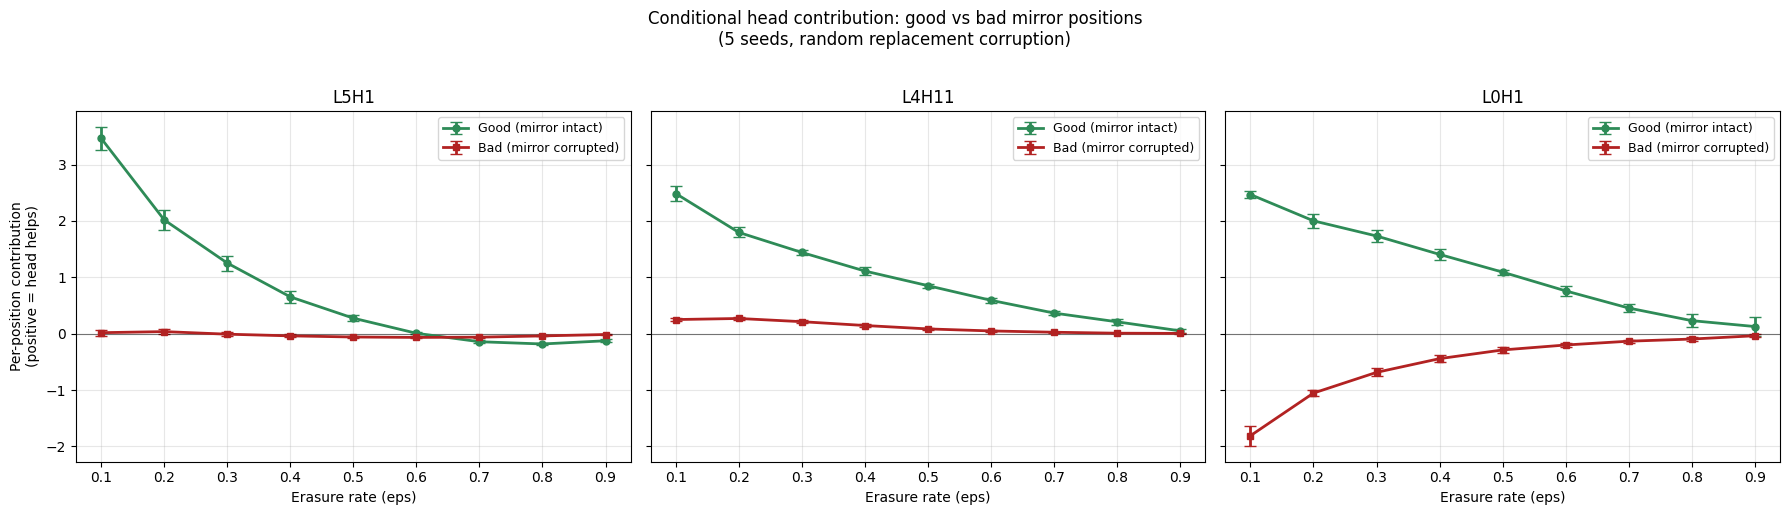

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (layer, head) in zip(axes, analysis_heads):
    r = cond_results[(layer, head)]

    ax.errorbar(eps_cond, r['good'], yerr=r['good_std'],
                fmt='o-', color='seagreen', label='Good (mirror intact)',
                linewidth=2, capsize=4, markersize=5)
    ax.errorbar(eps_cond, r['bad'], yerr=r['bad_std'],
                fmt='s-', color='firebrick', label='Bad (mirror corrupted)',
                linewidth=2, capsize=4, markersize=5)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Erasure rate (eps)')
    ax.set_title(f'L{layer}H{head}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel('Per-position contribution\n(positive = head helps)')

plt.suptitle('Conditional head contribution: good vs bad mirror positions\n'
             '(5 seeds, random replacement corruption)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/fig3e_conditional_contributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Validation: the weighted average of good and bad contributions should
# approximate the aggregate contribution from Part 5.
# net ≈ (1-eps) * good_contrib + eps * bad_contrib

print('L5H1 — conditional decomposition:')
print(f'{"eps":>5s}  {"good":>8s}  {"bad":>8s}  {"weighted_net":>12s}')
print('-' * 40)

r = cond_results[(5, 1)]
for i, eps in enumerate(eps_cond):
    good_val = r['good'][i]
    bad_val = r['bad'][i]
    weighted = (1 - eps) * good_val + eps * bad_val
    print(f'{eps:5.1f}  {good_val:+8.3f}  {bad_val:+8.3f}  {weighted:+12.3f}')

print('\nInterpretation:')
print('- Good positions: head consistently HELPS (positive contribution)')
print('- Bad positions: head consistently HURTS (negative contribution)')
print('- As eps increases, more positions are bad → net shifts toward negative')
print('- The crossover to net-harmful happens when eps * |bad| > (1-eps) * good')

L5H1 — conditional decomposition:
  eps      good       bad  weighted_net
----------------------------------------
  0.1    +3.465    +0.018        +3.120
  0.2    +2.019    +0.037        +1.622
  0.3    +1.253    -0.009        +0.874
  0.4    +0.653    -0.039        +0.376
  0.5    +0.275    -0.059        +0.108
  0.6    +0.007    -0.066        -0.037
  0.7    -0.143    -0.062        -0.086
  0.8    -0.183    -0.040        -0.068
  0.9    -0.126    -0.015        -0.026

Interpretation:
- Good positions: head consistently HELPS (positive contribution)
- Bad positions: head consistently HURTS (negative contribution)
- As eps increases, more positions are bad → net shifts toward negative
- The crossover to net-harmful happens when eps * |bad| > (1-eps) * good


## Conditional analysis: interpretation

The conditional split reveals the mechanistic story behind the harmful-head transition:

1. **On good positions** (mirror token intact), the head is **always helpful** — it finds the correct match in the first half and boosts the correct prediction. The contribution stays positive across all eps values.

2. **On bad positions** (mirror token corrupted), the head is **always harmful** — it attends to a wrong match and confidently copies the wrong token, actively hurting performance.

3. **The aggregate contribution is a weighted average:** `net ≈ (1-eps) * good + eps * bad`. At low eps, good positions dominate → net positive. At high eps, bad positions dominate → net negative.

This explains why the harmful-head effect is small even at high eps: the per-position harm on bad positions is modest (the head doesn't push *that* hard toward wrong tokens), and it only outweighs the per-position help on good positions when the vast majority of positions are corrupted.

**Key takeaway:** The head isn't "breaking" under corruption — it's doing exactly what it always does (attend to matching tokens and copy). The problem is that when the match is wrong, that same faithful copying mechanism hurts.

## Part 7: Bigram refinement — is next-token corruption the explanation?

L5H1 degrades on good mirrors at high eps. One hypothesis: it's not the mirror
that matters, but the *next* token (the one being predicted). If the next token
in the first half is corrupted, the bigram pattern is broken even though the
match is intact.

We split "good" into:
- **full_good**: mirror AND next token both intact
- **partial_good**: mirror intact but next token corrupted
- **bad**: mirror corrupted

In [21]:

# Bigram-refined conditional analysis: 3 buckets
# Bucket 1: mirror intact AND next intact ("full good")
# Bucket 2: mirror intact AND next corrupted ("partial good")
# Bucket 3: mirror corrupted ("bad")

def conditional_contributions_bigram(model, clean_tokens, corrupted_tokens, layer, head,
                                      eval_positions, eval_targets, n_ctx_half):
    mask = (corrupted_tokens[:, 1:1+n_ctx_half] != clean_tokens[:, 1:1+n_ctx_half])
    mirror_corrupted = mask[:, :n_ctx_half-1]
    next_corrupted = mask[:, 1:n_ctx_half]
    
    full_good = (~mirror_corrupted) & (~next_corrupted)
    partial_good = (~mirror_corrupted) & next_corrupted
    bad = mirror_corrupted
    
    with torch.no_grad():
        normal_logits = model(corrupted_tokens)
    normal_per_pos = logit_diff_per_position(normal_logits, eval_positions, eval_targets)
    
    with torch.no_grad():
        ablated_logits = ablate_head_logits(model, corrupted_tokens, layer, head)
    ablated_per_pos = logit_diff_per_position(ablated_logits, eval_positions, eval_targets)
    
    contribution = normal_per_pos - ablated_per_pos
    
    def safe_mean(t, m):
        return t[m].mean().item() if m.sum() > 0 else 0.0
    
    return (safe_mean(contribution, full_good),
            safe_mean(contribution, partial_good),
            safe_mean(contribution, bad),
            full_good.sum().item(), partial_good.sum().item(), bad.sum().item())

eps_cond = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
seeds_cond = list(range(5))

results_bigram = {'full_good': [], 'partial_good': [], 'bad': [],
                  'full_good_std': [], 'partial_good_std': [], 'bad_std': []}

for eps in eps_cond:
    fg_list, pg_list, b_list = [], [], []
    for seed in seeds_cond:
        corrupt_tok = corrupt_prefix_random_replace(
            tokens.cpu(), n_ctx_half=N_CTX_HALF, eps=eps, seed=seed
        ).to(device)
        fg, pg, b, _, _, _ = conditional_contributions_bigram(
            model, tokens, corrupt_tok, 5, 1,
            eval_positions, eval_targets, N_CTX_HALF
        )
        fg_list.append(fg)
        pg_list.append(pg)
        b_list.append(b)
    
    results_bigram['full_good'].append(np.mean(fg_list))
    results_bigram['partial_good'].append(np.mean(pg_list))
    results_bigram['bad'].append(np.mean(b_list))
    results_bigram['full_good_std'].append(np.std(fg_list))
    results_bigram['partial_good_std'].append(np.std(pg_list))
    results_bigram['bad_std'].append(np.std(b_list))
    print(f'eps={eps:.1f}: full_good={np.mean(fg_list):+.3f}, partial={np.mean(pg_list):+.3f}, bad={np.mean(b_list):+.3f}')


eps=0.1: full_good=+3.845, partial=+0.094, bad=+0.018
eps=0.2: full_good=+2.524, partial=+0.002, bad=+0.037
eps=0.3: full_good=+1.784, partial=-0.001, bad=-0.009
eps=0.4: full_good=+1.084, partial=-0.006, bad=-0.039
eps=0.5: full_good=+0.546, partial=-0.009, bad=-0.059
eps=0.6: full_good=+0.022, partial=-0.003, bad=-0.066
eps=0.7: full_good=-0.475, partial=-0.004, bad=-0.062
eps=0.8: full_good=-0.881, partial=-0.001, bad=-0.040
eps=0.9: full_good=-1.310, partial=-0.001, bad=-0.015


## Part 8: Sample count check + distractor-match analysis

The bigram split showed full_good going strongly negative at high eps (-1.31 at eps=0.9).
Two possible explanations:

1. **Small-sample noise:** At eps=0.9, P(both mirror and next survive) = 0.01.
   With batch=30 and 49 eval positions, that's ~15 cases per seed. The mean could be noisy.

2. **Distractor matches:** Even if the true mirror survives, random replacements
   can accidentally create duplicate tokens in the prefix. The induction head might
   attend to a *wrong* copy of the token instead of the true mirror, and copy the
   wrong next-token. This is "ambiguity from distractors."

We test both: first print sample counts, then split full_good by unique vs multi-match.

In [22]:
# Step 1: Print sample counts per bucket per eps
print('Sample counts per bucket (summed over batch=30 x 49 eval positions = 1470 total):')
print(f'{"eps":>5s}  {"full_good":>10s}  {"partial":>10s}  {"bad":>10s}')
print('-' * 42)

for eps in eps_cond:
    corrupt_tok = corrupt_prefix_random_replace(
        tokens.cpu(), n_ctx_half=N_CTX_HALF, eps=eps, seed=42
    ).to(device)

    mask = (corrupt_tok[:, 1:1+N_CTX_HALF] != tokens[:, 1:1+N_CTX_HALF])
    mirror_corrupted = mask[:, :N_CTX_HALF-1]
    next_corrupted = mask[:, 1:N_CTX_HALF]

    fg = ((~mirror_corrupted) & (~next_corrupted)).sum().item()
    pg = ((~mirror_corrupted) & next_corrupted).sum().item()
    bad = mirror_corrupted.sum().item()

    print(f'{eps:5.1f}  {fg:10d}  {pg:10d}  {bad:10d}')

print(f'\nAt eps=0.9, expected full_good ≈ 1470 * (0.1)^2 = {1470 * 0.01:.0f}')
print('If this is < 30, the mean is very unreliable.')

Sample counts per bucket (summed over batch=30 x 49 eval positions = 1470 total):
  eps   full_good     partial         bad
------------------------------------------
  0.1        1176         139         155
  0.2         932         237         301
  0.3         699         313         458
  0.4         492         353         625
  0.5         366         351         753
  0.6         233         345         892
  0.7         129         285        1056
  0.8          56         218        1196
  0.9          14         142        1314

At eps=0.9, expected full_good ≈ 1470 * (0.1)^2 = 15
If this is < 30, the mean is very unreliable.


In [23]:
# Step 2: Unique-match vs multi-match split for L5H1
#
# For each eval position, count how many times the current token appears
# in the corrupted prefix. If count == 1, the match is unambiguous.
# If count > 1, there are distractors.

def conditional_contributions_distractor(model, clean_tokens, corrupted_tokens, layer, head,
                                         eval_positions, eval_targets, n_ctx_half):
    """
    4-bucket split: full_good_unique, full_good_multi, partial_good, bad
    """
    mask = (corrupted_tokens[:, 1:1+n_ctx_half] != clean_tokens[:, 1:1+n_ctx_half])
    mirror_corrupted = mask[:, :n_ctx_half-1]
    next_corrupted = mask[:, 1:n_ctx_half]

    full_good = (~mirror_corrupted) & (~next_corrupted)
    partial_good = (~mirror_corrupted) & next_corrupted
    bad = mirror_corrupted

    # Count occurrences of each eval token in the corrupted prefix
    prefix = corrupted_tokens[:, 1:1+n_ctx_half]                        # [B, 50]
    dest_tokens = corrupted_tokens[:, 1+n_ctx_half:1+2*n_ctx_half-1]    # [B, 49]

    # occurrence_count[b, i] = # prefix positions matching dest_tokens[b, i]
    occurrence_count = (prefix.unsqueeze(2) == dest_tokens.unsqueeze(1)).sum(dim=1)  # [B, 49]

    unique = (occurrence_count == 1)
    multi = (occurrence_count > 1)

    full_good_unique = full_good & unique
    full_good_multi = full_good & multi

    # Compute contributions
    with torch.no_grad():
        normal_logits = model(corrupted_tokens)
    normal_per_pos = logit_diff_per_position(normal_logits, eval_positions, eval_targets)

    with torch.no_grad():
        ablated_logits = ablate_head_logits(model, corrupted_tokens, layer, head)
    ablated_per_pos = logit_diff_per_position(ablated_logits, eval_positions, eval_targets)

    contribution = normal_per_pos - ablated_per_pos

    def safe_mean(t, m):
        return t[m].mean().item() if m.sum() > 0 else 0.0

    return {
        'full_good_unique': safe_mean(contribution, full_good_unique),
        'full_good_multi': safe_mean(contribution, full_good_multi),
        'partial_good': safe_mean(contribution, partial_good),
        'bad': safe_mean(contribution, bad),
        'n_fg_unique': full_good_unique.sum().item(),
        'n_fg_multi': full_good_multi.sum().item(),
        'n_pg': partial_good.sum().item(),
        'n_bad': bad.sum().item(),
    }

# Run for L5H1
eps_cond = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
seeds_cond = list(range(5))

distractor_results = {k: [] for k in ['full_good_unique', 'full_good_multi', 'partial_good', 'bad',
                                       'fgu_std', 'fgm_std', 'pg_std', 'bad_std',
                                       'n_fg_unique', 'n_fg_multi']}

for eps in eps_cond:
    fgu_list, fgm_list, pg_list, b_list = [], [], [], []
    n_fgu_total, n_fgm_total = 0, 0
    for seed in seeds_cond:
        corrupt_tok = corrupt_prefix_random_replace(
            tokens.cpu(), n_ctx_half=N_CTX_HALF, eps=eps, seed=seed
        ).to(device)
        r = conditional_contributions_distractor(
            model, tokens, corrupt_tok, 5, 1,
            eval_positions, eval_targets, N_CTX_HALF
        )
        fgu_list.append(r['full_good_unique'])
        fgm_list.append(r['full_good_multi'])
        pg_list.append(r['partial_good'])
        b_list.append(r['bad'])
        n_fgu_total += r['n_fg_unique']
        n_fgm_total += r['n_fg_multi']

    distractor_results['full_good_unique'].append(np.mean(fgu_list))
    distractor_results['full_good_multi'].append(np.mean(fgm_list))
    distractor_results['partial_good'].append(np.mean(pg_list))
    distractor_results['bad'].append(np.mean(b_list))
    distractor_results['fgu_std'].append(np.std(fgu_list))
    distractor_results['fgm_std'].append(np.std(fgm_list))
    distractor_results['pg_std'].append(np.std(pg_list))
    distractor_results['bad_std'].append(np.std(b_list))
    distractor_results['n_fg_unique'].append(n_fgu_total // len(seeds_cond))
    distractor_results['n_fg_multi'].append(n_fgm_total // len(seeds_cond))

    print(f'eps={eps:.1f}: fg_unique={np.mean(fgu_list):+.3f} (n≈{n_fgu_total//len(seeds_cond)}), '
          f'fg_multi={np.mean(fgm_list):+.3f} (n≈{n_fgm_total//len(seeds_cond)}), '
          f'partial={np.mean(pg_list):+.3f}, bad={np.mean(b_list):+.3f}')

print('\nDistractor analysis done.')

eps=0.1: fg_unique=+3.848 (n≈1182), fg_multi=+0.725 (n≈1), partial=+0.094, bad=+0.018
eps=0.2: fg_unique=+2.527 (n≈936), fg_multi=-0.083 (n≈1), partial=+0.002, bad=+0.037
eps=0.3: fg_unique=+1.787 (n≈722), fg_multi=-0.035 (n≈1), partial=-0.001, bad=-0.009
eps=0.4: fg_unique=+1.088 (n≈532), fg_multi=-0.778 (n≈1), partial=-0.006, bad=-0.039
eps=0.5: fg_unique=+0.547 (n≈379), fg_multi=-0.053 (n≈0), partial=-0.009, bad=-0.059
eps=0.6: fg_unique=+0.021 (n≈238), fg_multi=+0.092 (n≈0), partial=-0.003, bad=-0.066
eps=0.7: fg_unique=-0.474 (n≈132), fg_multi=-0.164 (n≈0), partial=-0.004, bad=-0.062
eps=0.8: fg_unique=-0.881 (n≈62), fg_multi=+0.000 (n≈0), partial=-0.001, bad=-0.040
eps=0.9: fg_unique=-1.310 (n≈14), fg_multi=+0.000 (n≈0), partial=-0.001, bad=-0.015

Distractor analysis done.


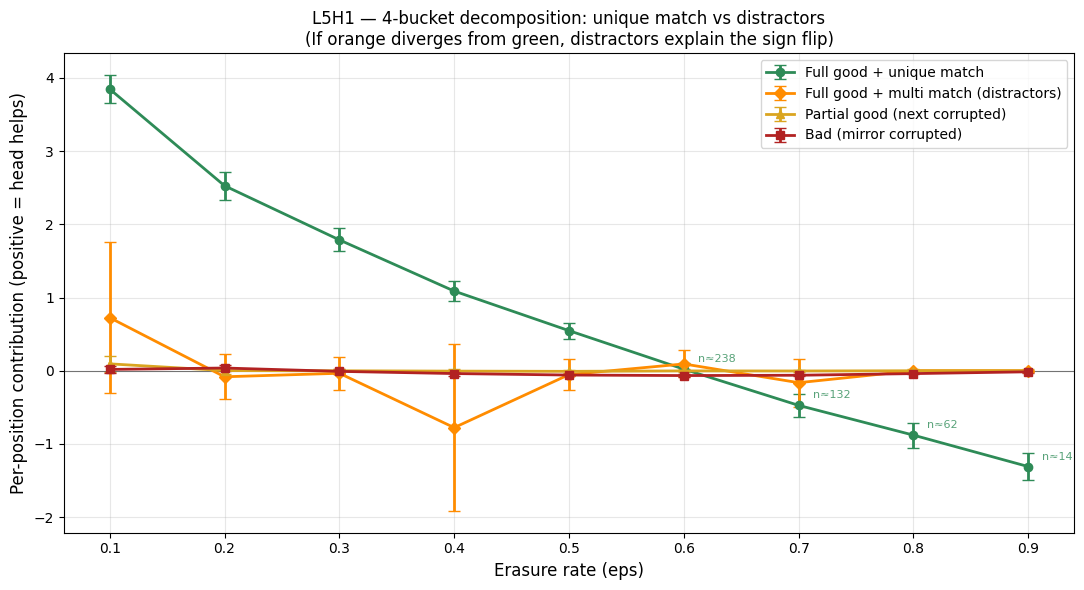

In [24]:
# The "final boss" plot: 4-bucket decomposition for L5H1
fig, ax = plt.subplots(figsize=(11, 6))

d = distractor_results
ax.errorbar(eps_cond, d['full_good_unique'], yerr=d['fgu_std'],
            fmt='o-', color='seagreen', label='Full good + unique match',
            linewidth=2, capsize=4, markersize=6)
ax.errorbar(eps_cond, d['full_good_multi'], yerr=d['fgm_std'],
            fmt='D-', color='darkorange', label='Full good + multi match (distractors)',
            linewidth=2, capsize=4, markersize=6)
ax.errorbar(eps_cond, d['partial_good'], yerr=d['pg_std'],
            fmt='^-', color='goldenrod', label='Partial good (next corrupted)',
            linewidth=2, capsize=4, markersize=6)
ax.errorbar(eps_cond, d['bad'], yerr=d['bad_std'],
            fmt='s-', color='firebrick', label='Bad (mirror corrupted)',
            linewidth=2, capsize=4, markersize=6)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Erasure rate (eps)', fontsize=12)
ax.set_ylabel('Per-position contribution (positive = head helps)', fontsize=12)
ax.set_title('L5H1 — 4-bucket decomposition: unique match vs distractors\n'
             '(If orange diverges from green, distractors explain the sign flip)',
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Annotate sample counts for full_good_unique at high eps
for i, eps in enumerate(eps_cond):
    if eps >= 0.6:
        ax.annotate(f'n≈{d["n_fg_unique"][i]}',
                   (eps, d['full_good_unique'][i]),
                   textcoords="offset points", xytext=(10, 5),
                   fontsize=8, color='seagreen', alpha=0.8)

plt.tight_layout()
plt.savefig('../results/figures/fig3g_distractor_analysis.png', dpi=150)
plt.show()